In [1]:
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.lines import Line2D

sc.set_figure_params(figsize=(5, 5))

In [2]:
adata = sc.read_h5ad("./heemskerk_data/adata_timeseries_old_48h-1_with_loop.h5ad")
meta = pd.read_csv("./heemskerk_data/MP_old_48-96h_new_D6-10_meta.csv", index_col=0)
adata.obs = meta.loc[adata.obs.index, :]

# HVG output

In [3]:
f = h5py.File("./heemskerk_data/Bonsai_48h-1_hvg/bonsai_vis_data.hdf", "r")
coords = f["layout_coords/node_coords/ly_eq_angle"][:]
edge_coords = f["layout_coords/edge_coords/ly_eq_angle"][:]
cell_inds = f["tree_info/cell_inds"][:]
int_inds = f["tree_info/int_inds"][:]
metadata = json.loads(f.attrs["metadata_json"])
cell_ids = metadata["cellIds"]
vert_to_cell = json.loads(f["vert_info"].attrs["vert_ind_to_cell_inds_json"])

cell_coords = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords[ci] = coords[vert_idx]
    else:
        cell_coords[cell_idx] = coords[vert_idx]
adata.obsm["X_bonsai"] = cell_coords
f.close()

<Axes: title={'center': 'leiden_sub'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

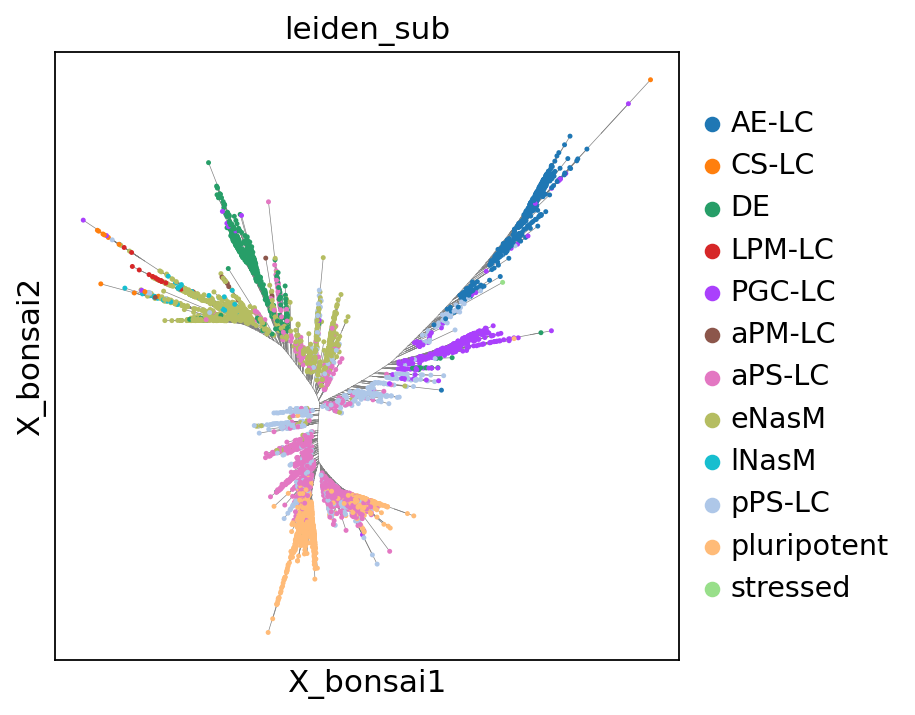

In [4]:
fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sc.pl.embedding(
    adata, basis="X_bonsai", color="leiden_sub", ax=ax, show=False, s=20, zorder=2
)

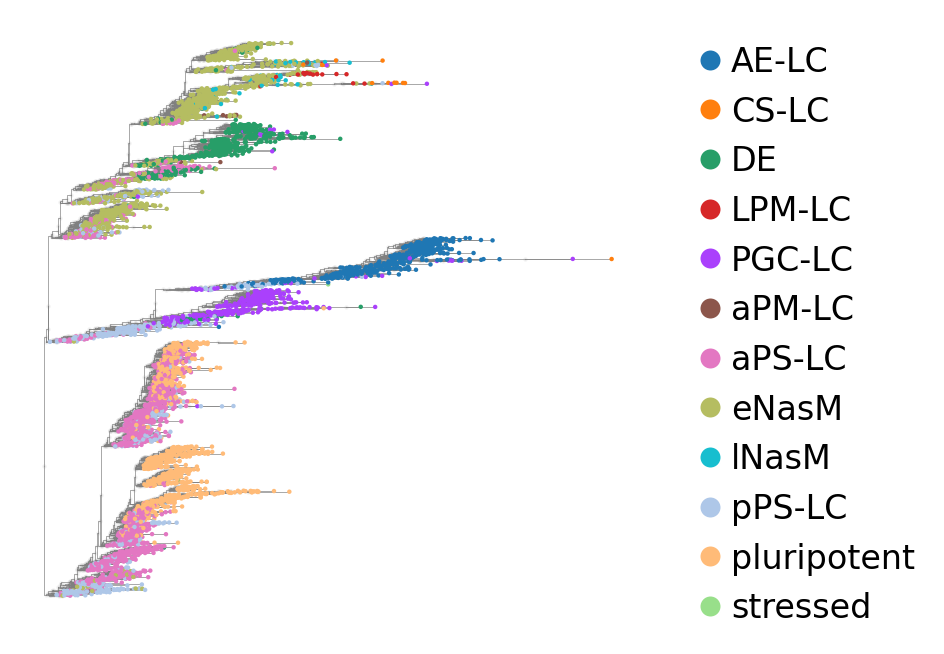

In [5]:
f = h5py.File("./heemskerk_data/Bonsai_48h-1_hvg/bonsai_vis_data.hdf", "r")
colors = adata.uns["leiden_sub_colors"]
categories = adata.obs["leiden_sub"].cat.categories
cat_to_color = dict(zip(categories, colors))
cell_colors = adata.obs["leiden_sub"].map(cat_to_color).values

coords_d = f["layout_coords/node_coords/ly_dendrogram_ladderized"][:]
edge_coords_d = f["layout_coords/edge_coords/ly_dendrogram_ladderized"][:]

cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(
    coords_d[int_inds, 0], coords_d[int_inds, 1], s=1, c="gray", alpha=0.1, zorder=2
)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")


handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=cat_to_color[c],
        markersize=10,
        label=c,
    )
    for c in categories
]
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")
f.close()

In [8]:
from my_tree_layout import Layout_Tree

node_id_to_vert_ind = {}
with open("./heemskerk_data/Bonsai_48h-1_hvg/final_bonsai/vertInfo.txt") as f:
    next(f)
    for line in f:
        parts = line.strip().split("\t")
        node_id_to_vert_ind[parts[2]] = int(parts[0])

with open("./heemskerk_data/Bonsai_48h-1_hvg/final_bonsai/tree.nwk") as f:
    nwk_str = f.read().strip()

ly_tree = Layout_Tree()
ly_tree.from_newick(nwk_str, node_id_to_vert_ind=node_id_to_vert_ind)
ly_tree.reset_root(node_id_to_vert_ind["internal_906"])
ly_tree.equalAngle()
coords = ly_tree.coords.copy()

(np.float64(-1.045),
 np.float64(1.0450000000000002),
 np.float64(-1.045),
 np.float64(1.045))

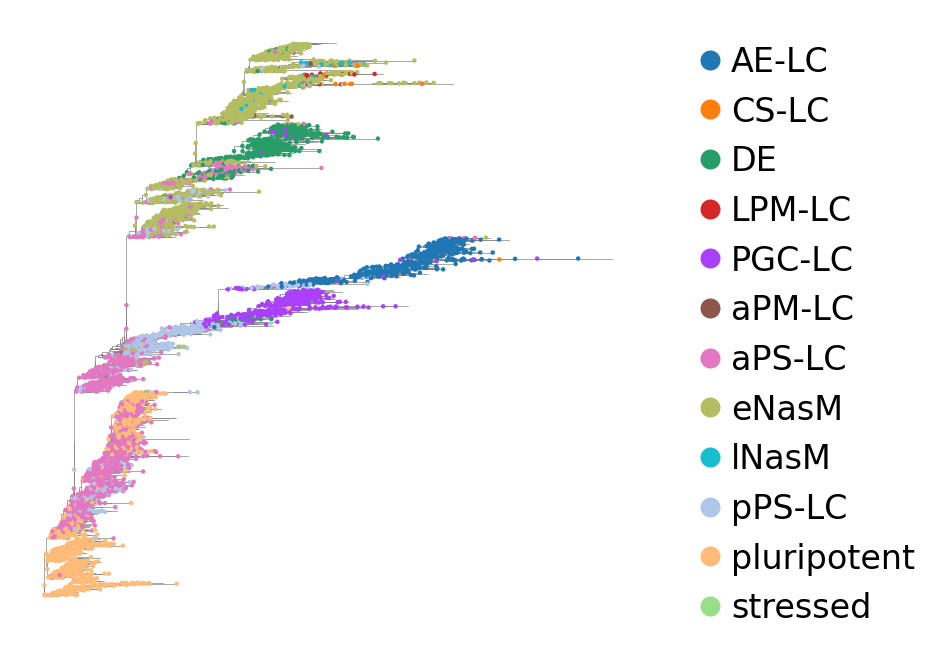

In [9]:
ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")

In [11]:
import sys

sys.path.insert(0, "/home/stan/Git/micropattern/Bonsai-data-representation")

from downstream_analyses.get_clusters_max_diameter import (
    get_annotation_based_clustering_from_nwk_str,
    get_cluster_assignments,
)

annotation_dict = adata.obs["leiden_sub"].to_dict()

with open("./heemskerk_data/Bonsai_48h-1_hvg/final_bonsai/tree.nwk") as f:
    nwk_str = f.read().strip()
clusters, cut_edges, nmi = get_annotation_based_clustering_from_nwk_str(
    tree_nwk_str=nwk_str, annotation_dict=annotation_dict, cutting_tol=0.005
)
cluster_dict = get_cluster_assignments({"annot": clusters})
adata.obs["bonsai_cluster"] = (
    cluster_dict["annot"].reindex(adata.obs.index).fillna("-1")
)
adata.obs["bonsai_cluster"] = adata.obs["bonsai_cluster"].astype(str).astype("category")

03-30 00:32:41 mp_print INFO Annotation-based clustering has done 2 moves, currently 3 clusters, and Normalized Mutual Information of 0.5515271657209468.
03-30 00:32:41 mp_print INFO Annotation-based clustering has done 4 moves, currently 5 clusters, and Normalized Mutual Information of 0.628842271477425.
03-30 00:32:42 mp_print INFO 
After making 7 clusters, norm. mutual information doesn't significantly increase. Stopping here.
03-30 00:32:42 mp_print INFO Final annotation-based clustering did 7 moves, created 7 clusters, with a Normalized Mutual Information of 0.6508135327758374.
03-30 00:32:42 mp_print INFO Clustering done


<Axes: title={'center': 'bonsai_cluster'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

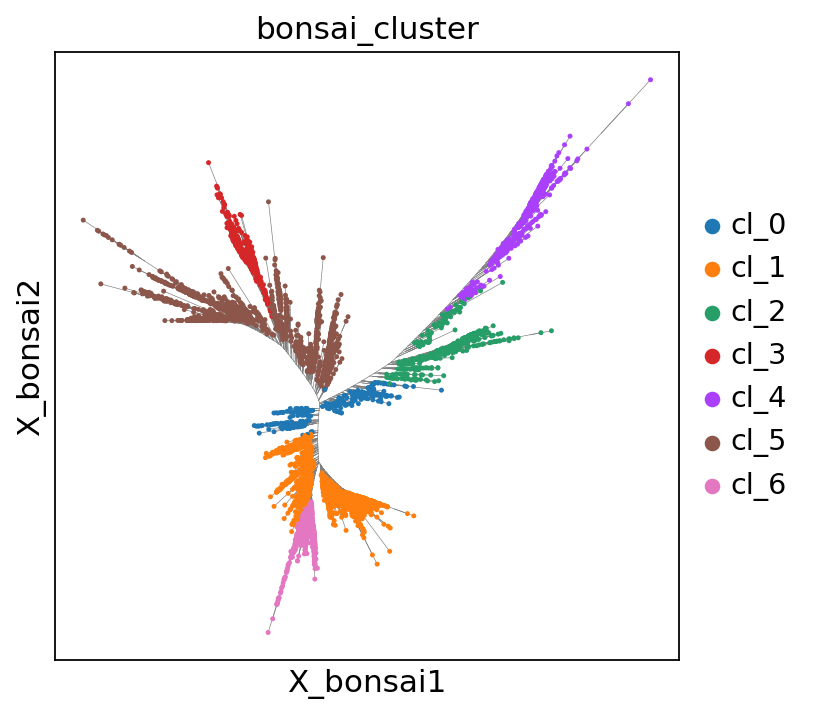

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sc.pl.embedding(
    adata, basis="X_bonsai", color="bonsai_cluster", ax=ax, show=False, s=20, zorder=2
)

(np.float64(-1.045),
 np.float64(1.0450000000000002),
 np.float64(-1.045),
 np.float64(1.045))

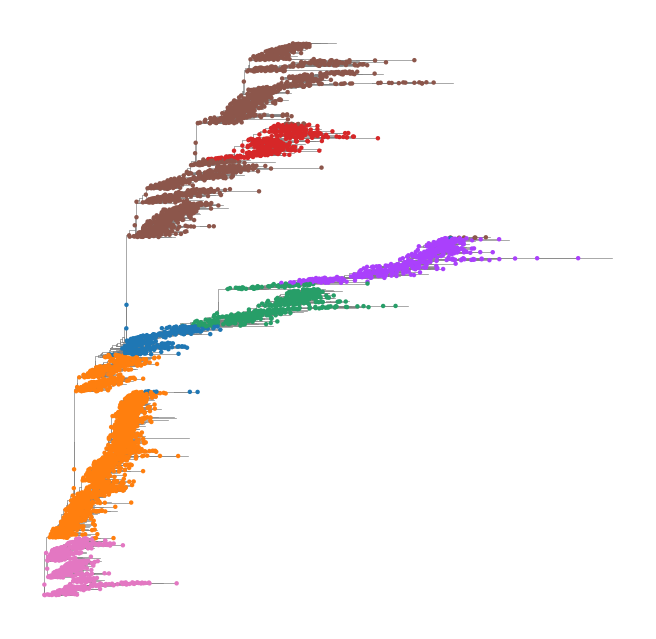

In [14]:
colors = adata.uns["bonsai_cluster_colors"]
categories = adata.obs["bonsai_cluster"].cat.categories
cat_to_color = dict(zip(categories, colors))
cell_colors = adata.obs["bonsai_cluster"].map(cat_to_color).values

ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")
ax.axis("off")

2707


(np.float64(-1.045),
 np.float64(1.0450000000000002),
 np.float64(-1.045),
 np.float64(1.045))

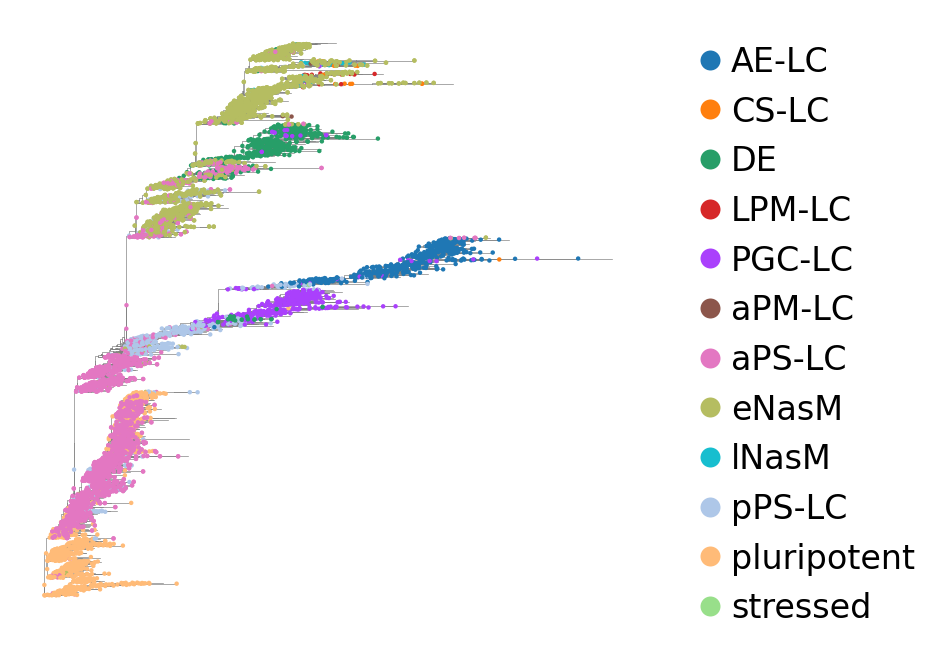

In [31]:
highlight_cells = np.concatenate(
    [
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"] == "DE",
                adata.obs["bonsai_cluster"].str.contains("cl_2|cl_0|cl_4"),
            )
        )[0],
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"] == "PGC-LC",
                adata.obs["bonsai_cluster"].str.contains("cl_3|cl_5"),
            )
        )[0],
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"].str.contains("eNasM|aPS-LC"),
                adata.obs["bonsai_cluster"].str.contains("cl_5"),
            )
        )[0],
        np.where(
            np.logical_and(
                adata.obs["leiden_sub"].str.contains("aPS-LC"),
                adata.obs["bonsai_cluster"].str.contains("cl_1"),
            )
        )[0],
    ]
)
print(len(highlight_cells))

colors = adata.uns["leiden_sub_colors"]
categories = adata.obs["leiden_sub"].cat.categories
cat_to_color = dict(zip(categories, colors))
cell_colors = adata.obs["leiden_sub"].map(cat_to_color).values
ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()
np.random.seed(1)
reorder_ind = np.random.permutation(cell_coords_d.shape[0])

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(
    cell_coords_d[reorder_ind, 0],
    cell_coords_d[reorder_ind, 1],
    s=1,
    c=cell_colors[reorder_ind],
    zorder=3,
)
ax.scatter(
    cell_coords_d[highlight_cells, 0],
    cell_coords_d[highlight_cells, 1],
    s=1,
    c=cell_colors[highlight_cells],
    zorder=5,
)
ax.set_aspect("auto")
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")